# Krittika Summer Projects 7.0: Computational Astronomy Assignment: Gravitational Lensing

This assignment explores the phenomenon of **gravitational lensing** through a sequence of computational and conceptual exercises. You will gradually build a working model simulation, beginning with classical optics and extending to relativistic light deflection by massive objects.

## Structure of the Assignment

The assignment is divided into multiple parts, each building on the previous one:

- (a) Classical thin lens optics  
- (b) Gravitational lensing: theory and derivation  
- (c) Simulation of lensing for a single point source  
- (d) Extension to extended sources  
- (e) Formation of Einstein rings  
- (f) Inverse problem: reconstruction of the source (graphically)
- (g) BONUS: Reconstruction of the source (bitmap image)

Each section introduces new ideas while reinforcing earlier ones. You are encouraged to move sequentially, but partial completion is fully acceptable.

## Expectations and Evaluation

This assignment is designed to prioritise **understanding over completion**.

- Partial attempts will be **valued and credited**
- Clear reasoning and explanation of your approach are important
- It is acceptable if some parts of the code do not fully work, as long as your thought process is evident

You should aim to:
- Show intermediate steps
- Explain assumptions or approximations
- Identify where difficulties arise

Submissions will be evaluated not only on correctness, but also on **clarity of reasoning and effort**.

## Role of Visualisation

A central component of this assignment is the use of **visualisation to understand physical systems**. You will use the Python library Matplotlib for all plotting tasks.

Visualisation is an essential tool in computational physics and is widely used in research contexts, including Krittika Summer Projects (KSPs). Producing clear, accurate, and interpretable plots is a fundamental skill.


## Matplotlib Guidelines

All plots in this assignment must be created using Matplotlib (refer https://matplotlib.org/stable/users/index.html for more information). For clarity and consistency, use small marker sizes while plotting points so that structure is not obscured:

```python
plt.scatter(x, y, s=3.5)
```
---


## Part (a): Classical Thin Lens Optics

Before moving to gravitational lensing, we begin with a familiar system from geometrical optics: the **thin convex lens**. This serves as an important conceptual and mathematical analogue for understanding how light rays are deflected and how images are formed.

In this part, you will analyse how a point source is imaged by a thin lens using both analytical expressions and graphical construction.

### Physical Setup

- Consider a **thin convex lens** placed along the vertical line \( x = 0 \), extending from \( y = -1.5 \) to \( y = +1.5 \).
- The lens has a **focal length** \( f = 1 \) (in arbitrary units).
- A point source is located at coordinates \( (x_0, y_0) \).


#### (i) Analytical Image Formation

- Given a point \( (x_0, y_0) \) (take user input as a floating point), compute the image position \( (x', y') \)
- Carefully consider and handle all possible cases.


#### (ii) Ray Diagram Construction

You will then construct a **graphical ray diagram** using Matplotlib:

- Draw a **horizontal incident ray** from the point source to the lens
- Show how this ray is refracted by the lens


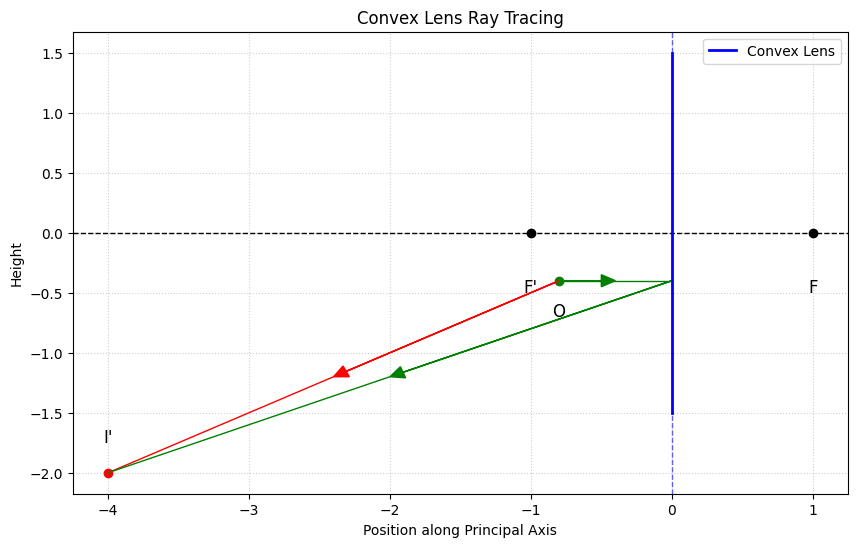

In [3]:
import matplotlib.pyplot as plt

#THIS FUNCTION TAKES POSITITON OF THE OBJECT AS INPUT (X_COOR,Y_COOR) AND GIVES A GRAPH AS OUTPUT.
def convex_lens(x,y):
    f = 1.0
    #SETTING THE PLOT
    fig,ax = plt.subplots(figsize=(10,6))

    #CALCULATION
    if abs(x)!=1:
        if x>0:
            x_1 = -x/(x-1)
            y_1 = -y/(x-1)
        elif x<0:
            x_1 = x/(x+1)
            y_1 = y/(x+1)

        #OBJECT AND IMAGE
        ax.plot(x, y, 'go')
        ax.plot(x_1, y_1, 'ro')
        ax.text(x, y-0.3, 'O', ha='center', fontsize=12)
        ax.text(x_1, y_1+0.25, "I'", ha='center', fontsize=12)

        #LINES
        ax.plot([x,x_1],[y,y_1], color='red', linewidth=1,)
        ax.arrow(x, y, (x_1-x)/2, (y_1-y)/2, head_width=0.1, head_length=0.1, 
                fc='red', ec='red', length_includes_head=True)
        
        #HEIGHT OF OBJECT LESS THAN APERTURE
        ax.plot([x,0],[y,y], color='green', linewidth=1)
        ax.plot([x_1,0],[y_1,y], color='green', linewidth=1)
        ax.arrow(x, y, (0-x)/2,0, head_width=0.1, head_length=0.1, 
            fc='green', ec='green', length_includes_head=True)
        ax.arrow(0, y, (x_1-0)/2, (y_1-y)/2, head_width=0.1, head_length=0.1, 
            fc='green', ec='green', length_includes_head=True)
        
    #INF CASE
    elif abs(x)==1:
        x_end = -5 if x>0 else 5
        y_end = y*x_end/x

        #OBJECT
        ax.plot(x, y, 'go')
        ax.text(x, y-0.3, 'O', ha='center', fontsize=12)

        #LINES
        ax.plot([x,x_end],[y,y_end], color='red', linewidth=1,)
        ax.arrow(x, y, (x_end-x)/2, (y_end-y)/2, head_width=0.1, head_length=0.1, 
                fc='red', ec='red', length_includes_head=True)
        
        ax.plot([x,0],[y,y], color='green', linewidth=1)
        ax.arrow(x, y, (0-x)/2,0, head_width=0.1, head_length=0.1, 
            fc='green', ec='green', length_includes_head=True)
        ax.arrow(0, y,y_end/y*x , y_end, head_width=0.1, head_length=0.1, 
            fc='green', ec='green', length_includes_head=True)


    #PRINCIPAL AXIS AND LENS
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.axvline(0, color='blue', linewidth=1, linestyle='--',alpha=0.6)
    ax.plot([0,0],[-1.5,1.5], color='blue', linewidth=2, label='Convex Lens')

    #FOCAL POINTS
    ax.plot([f, -f], [0, 0], 'ko')
    ax.text(f, -0.5, 'F', ha='center', fontsize=12)
    ax.text(-f, -0.5, "F'", ha='center', fontsize=12)



    ax.set_xlabel('Position along Principal Axis')
    ax.set_ylabel('Height')
    ax.set_title('Convex Lens Ray Tracing')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.show()


#CHANGE THE VALUES OF X,Y HERE TO SEE DIFFERENT IMAGE POSITIONS AND RAY DIAGRAMS.
convex_lens(-0.8,-.4)

## Part (b): Gravitational Lensing — Theory

In this part, you will study how a massive object bends light and produces multiple images of a source.

![Gravitational Lensing Diagram](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/0b3c4e750f8e8473750b947bc84eb1a49259c091/Computational_Astronomy/Grav_Lensing_Diagram.png)

### Key Relations

Deflection angle:
$$
\tilde{\alpha} = \frac{4GM}{c^2 \xi}, \quad \xi = d_L \tan\theta
$$

Lens equation:
$$
\theta = \beta + \frac{d_{LS}}{d_S}\tilde{\alpha}
$$

Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2}\frac{d_{LS}}{d_L d_S}}
$$


### Task

- Solve the **exact equation** numerically  
- Find an approximate equation for situations $\theta_E$ is small. Solve the **approximate equation** analytically.
- Compute and plot the **percentage error** vs $\,\beta / \theta_E\,$  Identify the breakaway point where the error starts growing out of bounds.

<br><br>
## **Answer**
Exact Equation

$$\theta_E^2 = \tan\theta(\theta-\beta)$$

Approximation of the above equation, as $\lim_{\theta \to 0}$

$$\theta^2-\theta\beta-\theta_E^2=0$$
Solving this, we get:

$$\theta = \dfrac{\beta \pm \sqrt{\beta^2+4\theta_E^2}}{2}$$

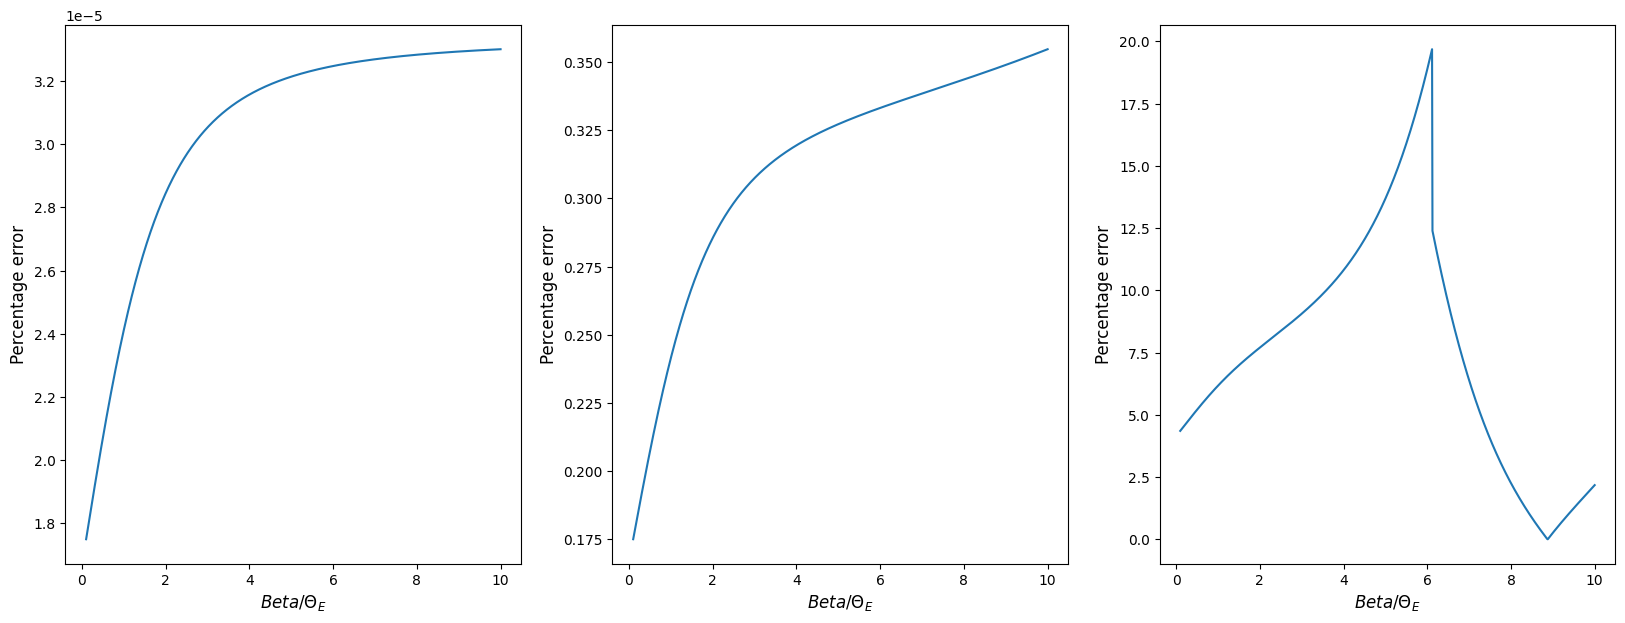

In [31]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt


ratios = np.linspace(0.1,10.0,1000) # taking 1/10th to 10 times of the THETA_E

# defined the function which will output percent error array.
def lensing(THETA_E):

    BETA_VALUES = ratios*THETA_E

    theta_approx_list = []
    theta_exact_list = []

    for beta in BETA_VALUES:
        theta_approx = (beta + np.sqrt(beta**2 + 4*THETA_E**2))/2

        def exact_t(theta):
            return theta - beta - THETA_E**2/np.tan(theta)
        
        theta_exact = fsolve(exact_t,x0 = theta_approx)[0]

        theta_approx_list.append(theta_approx)
        theta_exact_list.append(theta_exact)

    theta_approx_array = np.array(theta_approx_list)
    theta_exact_array = np.array(theta_exact_list)

    percent_error = np.abs((theta_exact_array - theta_approx_array)/theta_exact_array*100)

    return percent_error


# FOR 3 DIFFERENT VALUES OF THETA_E, 10^-3, 0.1 AND 0.5.
plt.figure(figsize=(20,7))
plt.subplot(1,3,1)
percent_error = lensing(1e-3)
plt.plot(ratios,percent_error)
plt.xlabel(r"$Beta/\Theta_E$",fontsize=12)
plt.ylabel("Percentage error",fontsize=12)

plt.subplot(1,3,2)
percent_error = lensing(0.1)
plt.plot(ratios,percent_error)
plt.xlabel(r"$Beta/\Theta_E$",fontsize=12)
plt.ylabel("Percentage error",fontsize=12)

plt.subplot(1,3,3)
percent_error = lensing(0.5)
plt.plot(ratios,percent_error)
plt.xlabel(r"$Beta/\Theta_E$",fontsize=12)
plt.ylabel("Percentage error",fontsize=12)

plt.show()



WE SEE DIFFERENT PATTERNS FOR THE THREE VALUES OF THETA, AND BREAKING POINT OCCURS IN GRAPH 3, ONLY WHEN $\theta_E$ IS SIGNIFICANT(AROUND $28^\circ$). 
WE ALSO CONCLUDE THAT IF $\theta_E$ IS QUITE SMALL, THEN THE PERCENTAGE ERROR IS VERY SMALL IRRESPECTIVE OF THE RATIO.
<br>
<br>
<br>
<br>
<br>

## Part (c): Simulation of a Single Lensed Point Source

In this part, you will simulate gravitational lensing of a **single point source** by a massive object placed at the origin.

Assume the following constants (fixed for the simulation):
$$
d_L = 5.00 \times 10^{11}\,\text{m}, \quad
d_S = 9.75 \times 10^{17}\,\text{m}, \quad
d_{LS} = 9.75 \times 10^{17}\,\text{m}
$$

Using these, compute the Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2} \cdot \frac{d_{LS}}{d_L d_S}}
$$

### Task

Given a source position $S = (x, y)$:
-Plot:
   - Source point
   - Image(s)
   - Lens at origin

### Cases to Explore

(i) Source on x/y axis (aligned cases)

(ii) Source off-axis (general cases)

---

<br>

## **Answer**

![Assumtion_Lensing](part(c).jpeg)

<br>
Assumtions:

1. The picture attached above is how I see the question being framed. x,y are in radians, and the source observer are arranged in the manner shown.

2. I will assume Beta angle to be small enough for the approximation in the previous question to hold true(since $\theta_E$ is quite small).

I will solve the problem according to these assumptions. **i didn't use normalised angular space.**


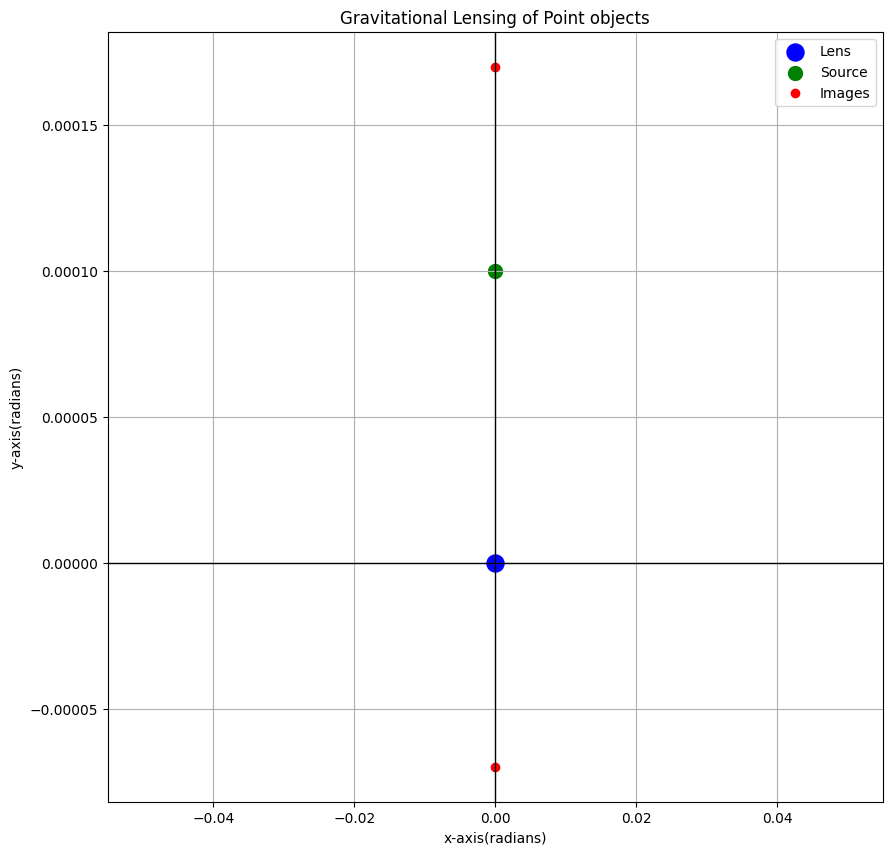

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



def point_source_lensing(Mass,x,y): # Mass of the lens, x,y of the point source.
    
    dl,ds,dls = 5.00 * 10**11,9.75 * 10**17,9.75 * 10**17
    c = 299792458
    G = 6.674*10**-11

    theta_E = np.sqrt(4*G*Mass*dls/(c**2*ds*dl))
    beta = np.sqrt(x**2+y**2)

    theta_1 = (beta + np.sqrt(beta**2+4*theta_E**2))/2
    theta_2 = (beta - np.sqrt(beta**2+4*theta_E**2))/2

    fig,ax = plt.subplots(figsize=(10,10))
    ax.axhline(0, color='black', linewidth=1, linestyle='-')
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.scatter(0,0, color='blue',s=150, label='Lens')
    ax.scatter(x,y,color='green',s=100,label='Source')
    
    
    phi = np.arctan2(y, x)
    x_1, y_1 = np.round(theta_1*np.cos(phi), 10), np.round(theta_1*np.sin(phi), 10)
    x_2, y_2 = np.round(theta_2*np.cos(phi), 10), np.round(theta_2*np.sin(phi), 10)

    ax.scatter([x_1,x_2],[y_1,y_2], color='red', label='Images')


    if y==0 and x==0:
        ring = plt.Circle((0.0, 0.0),theta_E, color='red', fill=False,label='Einstein Ring')

        ax.add_patch(ring)

        ax.set_xlim(-theta_E * 2, theta_E * 2)
        ax.set_ylim(-theta_E * 2, theta_E * 2)
        ax.set_aspect('equal')



    plt.grid()
    plt.title('Gravitational Lensing of Point objects')
    plt.xlabel("x-axis(radians)")
    plt.ylabel("y-axis(radians)")
    plt.legend()
    plt.show()


#Input values of your wish and see the result below. 
#Input Mass,x,y
point_source_lensing(2*10**30,0,10**-4)



## Part (d): Extended Sources

In this part, you will extend your simulation from a single point source to an **extended source**, modelled as a collection of multiple points.

Assume the source is a small circular region centred at $(x_0, y_0)$ with radius $R$. This can be approximated by sampling many points within the circle.

### Task
Plot:
   - Original source points (blue, small markers)
   - Corresponding lensed image points (red/yellow)

### Suggested Parameters

- Number of points: 150–300  

### Notes

- Use very small marker sizes ($s \leq 5$) for clarity  
- You should observe distortion of the circular source near alignment  
- You can plot both source points and image points on the same plane by considering angular variation only (i.e., plotting the points in terms of $\theta_x$ and $\theta_y$, where $\theta_x$, $\theta_y$ represent the angular separation from the source in the x and y directions).

---

## **Answer**

I will take the Radius in radians, to maintain the flow of the discussion. (Radius should be considerate value and in according to the question.


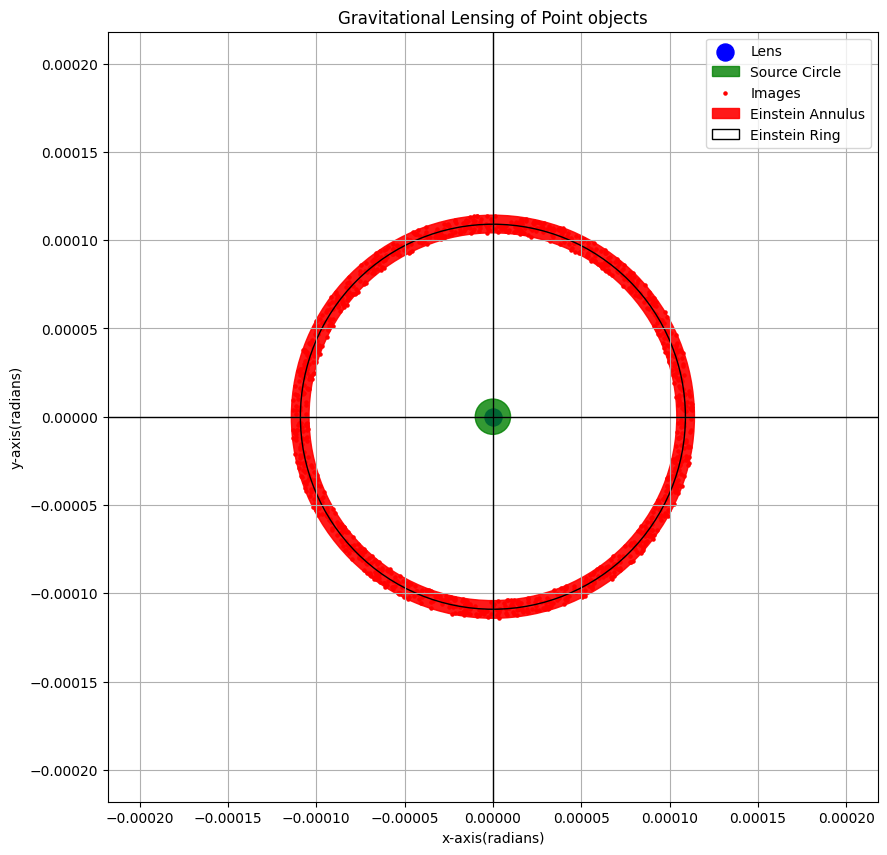

In [63]:
from matplotlib.patches import Wedge

def extended_source_lensing(Mass,x,y,R): # Mass of the lens, x,y,R of the centre and radius of the source.
    #GENERATING RANDOM N POINTS
    N = 600
    theta = np.random.uniform(0,2*np.pi,N)
    r = np.random.uniform(0,R,N)

    x_0,y_0 = x + r*np.cos(theta), y + r*np.sin(theta)

    #CALCULATION
    dl,ds,dls = 5.00 * 10**11,9.75 * 10**17,9.75 * 10**17
    c = 299792458
    G = 6.674*10**-11

    theta_E = np.sqrt(4*G*Mass*dls/(c**2*ds*dl))
    beta = np.sqrt(x_0**2+y_0**2)

    theta_1 = (beta + np.sqrt(beta**2+4*theta_E**2))/2
    theta_2 = (beta - np.sqrt(beta**2+4*theta_E**2))/2

    phi = np.arctan2(y_0,x_0) 

    x_1,y_1 = theta_1*np.cos(phi),theta_1*np.sin(phi)
    x_2,y_2 = theta_2*np.cos(phi),theta_2*np.sin(phi)

    #DRAWING THE GRAPH, AXES,LENS
    fig,ax = plt.subplots(figsize=(10,10))
    ax.axhline(0, color='black', linewidth=1, linestyle='-')
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.scatter(0,0, color='blue',s=150, label='Lens')

    #THE SOURCE CIRCLE
    source = plt.Circle((x,y),R, color='green', fill=True,label='Source Circle',alpha=0.8)
    ax.add_patch(source)
    ax.set_aspect('equal')

    #IMAGES
    ax.scatter([x_1,x_2],[y_1,y_2], color='red',s=5, label='Images')


    #EINSTEIN'S ANNULUS
    if x==0 and y==0:
        theta_1 = (R + np.sqrt(R**2+4*theta_E**2))/2

        #WIDTH OF ANNULUS IS THETA_1 - THETA_2 = R, RADIUS OF THE SOURCE. 
        annulus = Wedge((0, 0), theta_1, 0, 360, width=R, 
              color='red', alpha=0.9, label='Einstein Annulus')
        e_ring = plt.Circle((0.0, 0.0),theta_E, color='black', fill=False,label='Einstein Ring')
        ax.add_patch(annulus)
        ax.add_patch(e_ring)

        ax.set_xlim(-theta_E * 2, theta_E * 2)
        ax.set_ylim(-theta_E * 2, theta_E * 2)



    plt.grid()
    plt.title('Gravitational Lensing of Point objects')
    plt.xlabel("x-axis(radians)")
    plt.ylabel("y-axis(radians)")
    plt.legend()
    plt.show()

#Input values of your wish and see the result below. 
#Input Mass,x,y
extended_source_lensing(2*10**30,0,0,10**-5)

## Part (e): Formation of an Einstein Ring

In this part, you will study how an **Einstein ring** forms as the source becomes increasingly aligned with the lens.

### Task

1. Consider a point source located along the vertical axis:
   $$
   S = (0, y)
   $$

2. Choose a sequence of source positions approaching perfect source-lens alignment along vertical axis.

3. Create **five separate plots**, one for each value of $y$:
   - Plot the source (blue)
   - Plot both image positions (red/yellow)
   - Plot the lens at the origin (black)

### Notes
- Ensure consistent axis limits across all plots for comparison  


## **Answer**

I will take values of y as  $\{10^{-4},10^{-5},10^{-8},10^{-10},0\}$

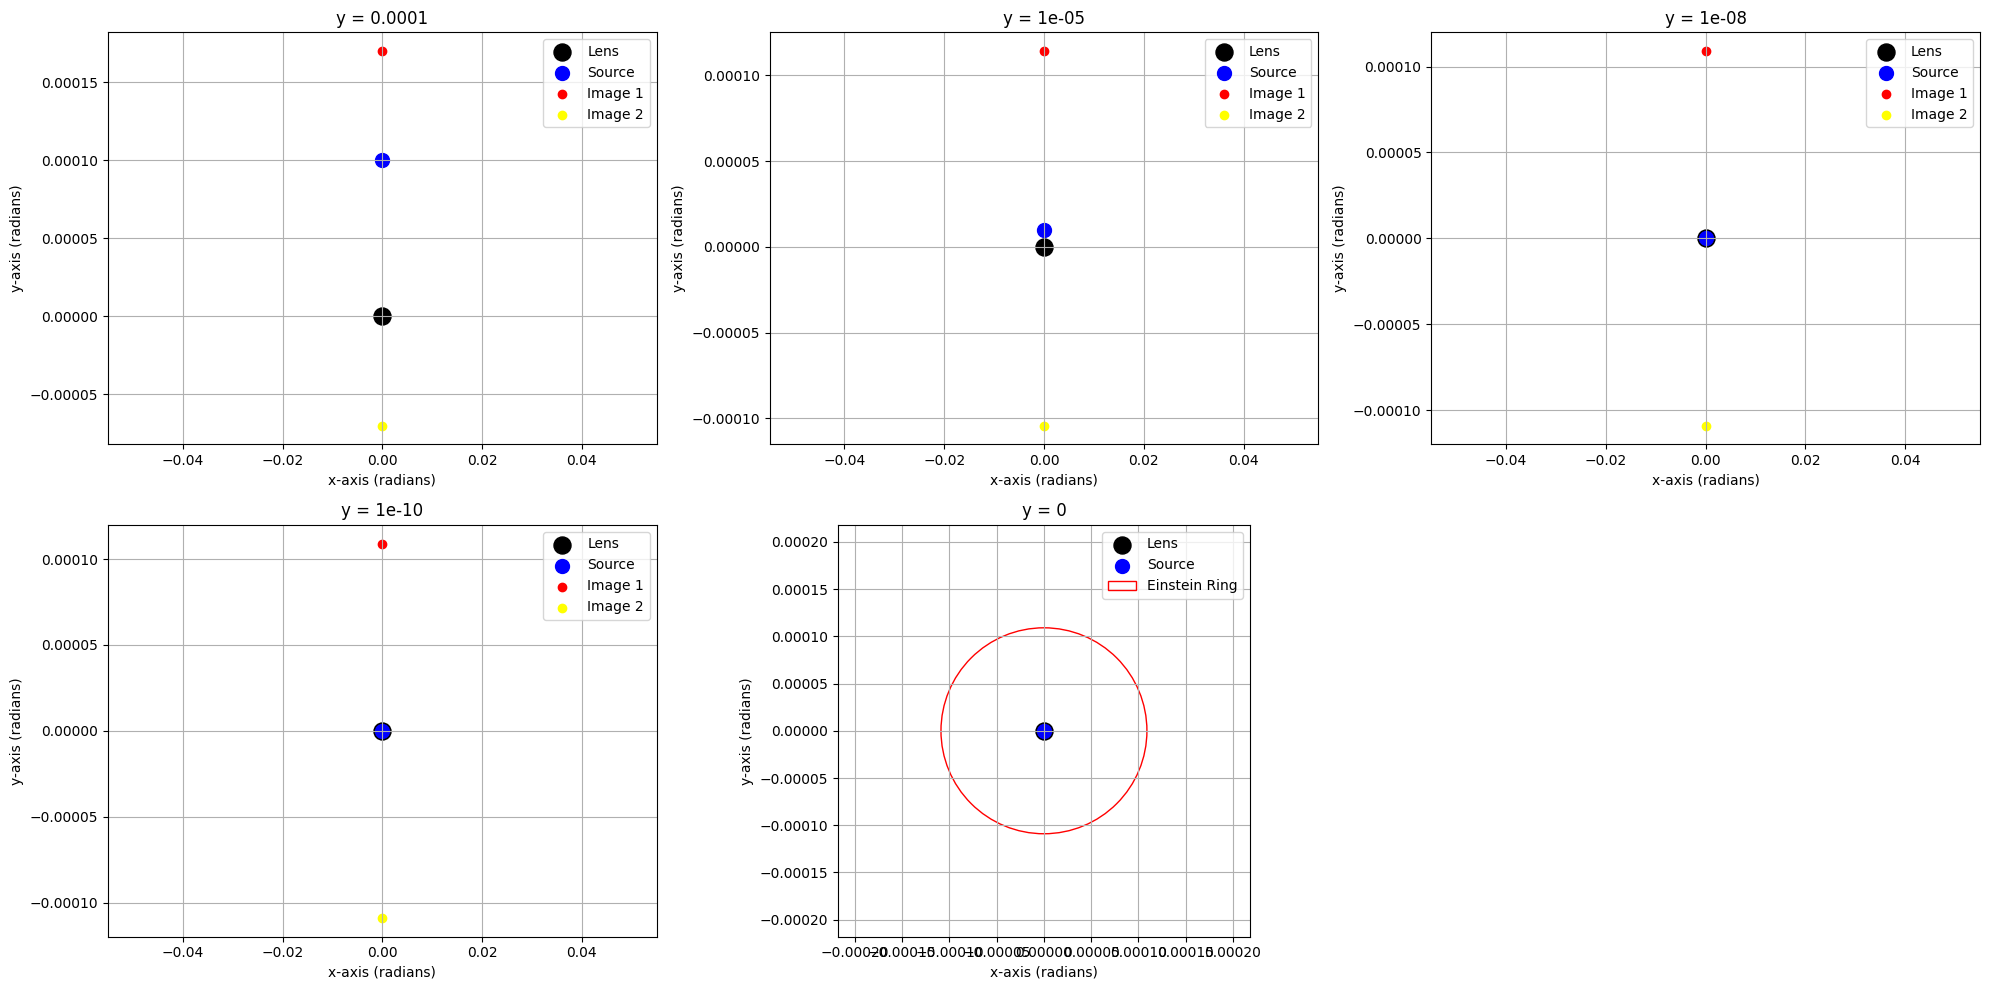

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def einstein_ring(Mass,x,y_array): # Mass of the lens, x,y of the point source. Here y is an array of 5 elements.
    
    dl,ds,dls = 5.00 * 10**11,9.75 * 10**17,9.75 * 10**17
    c = 299792458
    G = 6.674*10**-11

    theta_E = np.sqrt(4*G*Mass*dls/(c**2*ds*dl))
    



    fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,10))
    ax = ax.flatten()

    i=0
    for y in y_array:
        beta = np.sqrt(x**2+y**2)
        theta_1 = (beta + np.sqrt(beta**2+4*theta_E**2))/2
        theta_2 = (beta - np.sqrt(beta**2+4*theta_E**2))/2

        ax[i].scatter(0,0, color='black',s=150, label='Lens')
        ax[i].scatter(x,y,color='blue',s=100,label='Source')

        if y==0 and x==0:
            ring = plt.Circle((0.0, 0.0),theta_E, color='red', fill=False,label='Einstein Ring')

            ax[i].add_patch(ring)

            ax[i].set_xlim(-theta_E * 2, theta_E * 2)
            ax[i].set_ylim(-theta_E * 2, theta_E * 2)
            ax[i].set_aspect('equal')
        
        else:
            phi = np.arctan2(y, x)
            x_1, y_1 = np.round(theta_1*np.cos(phi), 10), np.round(theta_1*np.sin(phi), 10)
            x_2, y_2 = np.round(theta_2*np.cos(phi), 10), np.round(theta_2*np.sin(phi), 10)

            ax[i].scatter([x_1],[y_1], color='red', label='Image 1')
            ax[i].scatter([x_2],[y_2], color='yellow', label='Image 2')

        
        ax[i].set_title(f'y = {y}')
        ax[i].set_xlabel("x-axis (radians)")
        ax[i].set_ylabel("y-axis (radians)")
        ax[i].grid(True,)
        ax[i].legend()
        i+=1

    ax[-1].set_visible(False)
    plt.tight_layout()
    plt.show()

y_array = (10**-4,10**-5,10**-8,10**-10,0)
einstein_ring(2*10**30,0,y_array)

## Part (f): Original Image Reconstruction from Lensed Image

For this part, you are provided a set of points, that represents the lensed image of a celestial body. The coordinates of the lens are given to be (0, 0).
Use the provided [lensed_points.csv](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/lensed_points.csv)
### Task:

1. Derive the inverse transformation to find the set of coordinates corresponding to the original image.
2. Consider a celestial object represented by the set of coordinates in the .csv file. These represent the coordinates in the normalised angular space (i.e. in terms of $\theta_x/\theta_E$ and $\theta_y/\theta_E$).
3. Use the derived transformation to find the set of coordinates for the actual image. Plot it, using a suitable scale.

(array([], dtype=int64),)


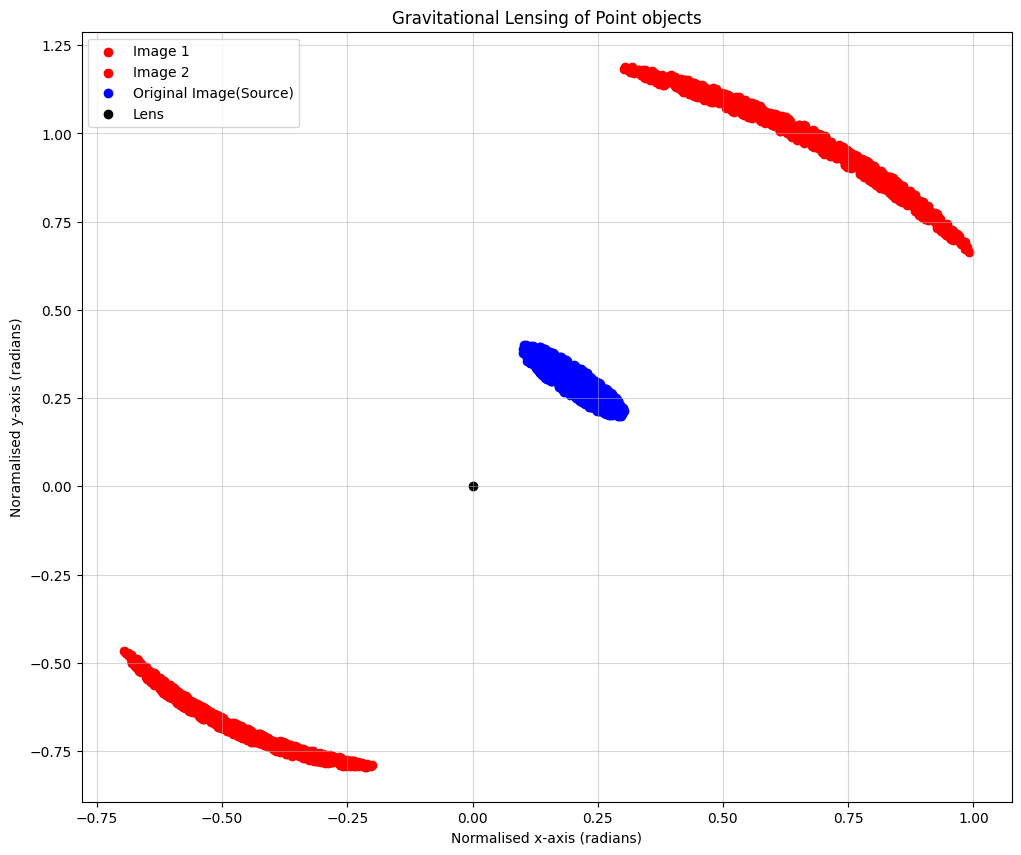

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lensed_points = np.loadtxt('lensed_points.csv', delimiter=',',skiprows=1)

x_1,y_1,x_2,y_2 = lensed_points[:,0],lensed_points[:,1],lensed_points[:,2],lensed_points[:,3]

#ANGLE AT WHICH THE CORRESPONDING SOURCE POINT IS PRESENT.
phi1 = np.arctan2(y_1,x_1)
phi2 = np.arctan2(y_2,x_2)

bool = np.where((phi1-phi2).round(6)!=np.round(np.pi, 6))
print(bool) #PRINTS EMPTY ARRAY
#FROM THIS WE CAN SEE, THE X_1,Y_1 AND X_2,Y_2 HAVE THE SAME SOURCE POINT.
#THIS WILL BE MY ASSUMPTION FROM NOW ON.

#RETRACING THE STEPS OF LENSING
PHI = phi1

theta_1 = np.sqrt(x_1**2+y_1**2)
theta_2 = np.sqrt(x_2**2+y_2**2)

theta = abs(theta_1 - theta_2)  
# ONE ROOT IS POSITIVE AND THE OTHER IS NEGATIVE, SO TOOK THE DIFFERENCE AND POSITIVE ROOT IS GREATER, SO TOOK ABSOLUTE VALUE

x_source = theta*np.cos(PHI)
y_source = theta*np.sin(PHI)

#PLOTTING
fig,ax = plt.subplots(figsize=(12,10))
ax.scatter(x_1,y_1,color='red',label="Image 1")
ax.scatter(x_2,y_2,color='red',label="Image 2")
ax.scatter(x_source,y_source,color='blue',label="Original Image(Source)")
ax.scatter(0,0,color='black',label="Lens")

plt.grid(True,alpha=0.5)
plt.title('INVERSE LENSING')
plt.xlabel("Normalised x-axis (radians)")
plt.ylabel("Noramalised y-axis (radians)")
plt.legend()
plt.show()

## Part (g): Bonus Question
You are provided with an actual 24-bit bitmap image ([hubble-lrg3757.bmp](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/hubble-lrg3757.bmp)) of a lensed galaxy, a nearly perfect Einstein Ring (Source: [NASA - LRG 3-757](https://science.nasa.gov/image-detail/einstein-ring-lrg-3-757/)). Use the transformation derived earlier and find the actual, de-lensed image of the galaxy (what the galaxy would look like if the original foreground cluster were not present).
![LRG 3-757](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/refs/heads/main/Computational_Astronomy/hubble-lrg3757.bmp)
### Task:
1. Import the image as a NumPy array. (Convert to Grayscale if necessary)
2. Write a script to map the pixels of the lensed image back to their source positions, You may have to crop the image suitably, use thresholding to identify bright regions of the image. You may refer to the OpenCV documentation here:- https://docs.opencv.org/4.x/index.html
3. Use $d_L$ = 6.3 $\times$ $10^9$ light years, $d_S$ = 10.9 $\times$ $10^9$ light years (refer to the diagram for the notation).

Value of Theta_E( in radians ) is 6.467489477147719e-06


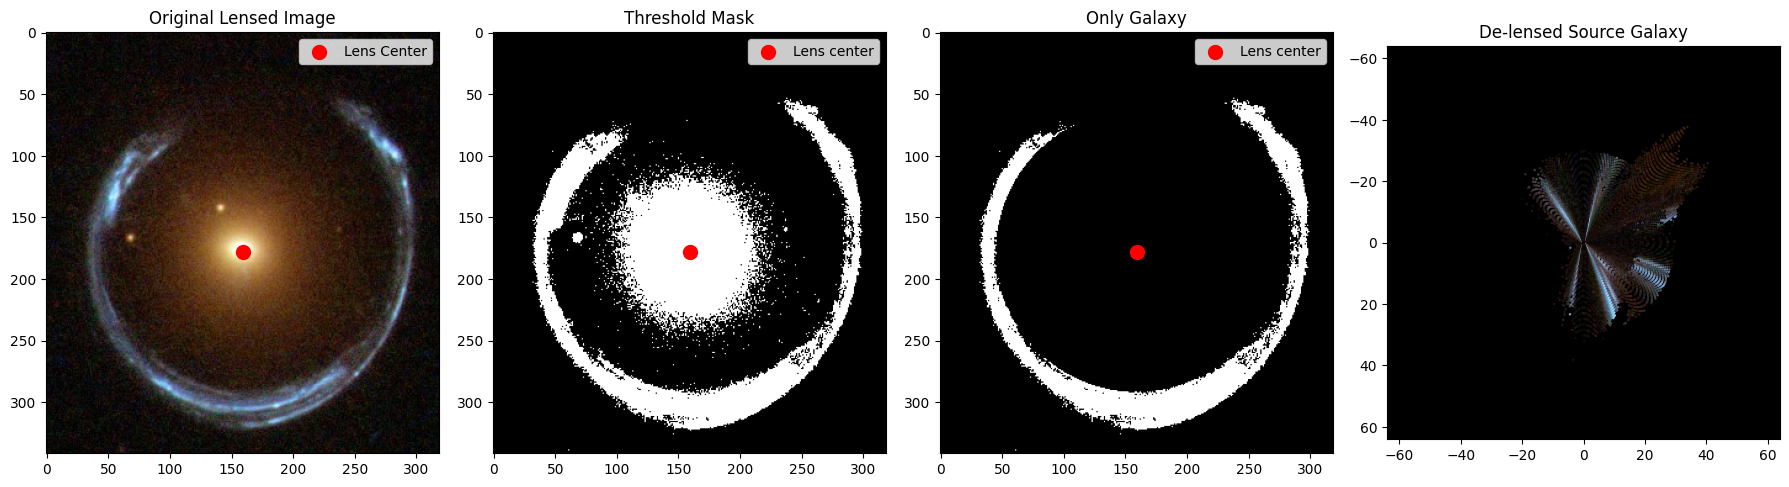

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# LOAD THE IMAGE
img_gray = cv2.imread('/home/maulik/Documents/KSP-7.0-Assignment/Coding Assignment/hubble-lrg3757.bmp', cv2.IMREAD_GRAYSCALE)
img_color = cv2.imread('/home/maulik/Documents/KSP-7.0-Assignment/Coding Assignment/hubble-lrg3757.bmp', cv2.IMREAD_COLOR)
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# CALCULATED THIS FROM hubble_coordinates.py output by hovering over it
y_start = 303 
y_end = 645
x_start = 606
x_end = 925

#CROPPED THE IMAGE TO JUST THE GALAXY AND LENS.
img_gray = img_gray[y_start:y_end, x_start:x_end]
img_color = img_color[y_start:y_end, x_start:x_end]

# CALCULATION THETA_E (WE DONT NEED IT ANYWAY)
ly  = 9.461e15                   # 1 light-year in metres
dl  = 6.3e9  * ly
ds  = 10.9e9 * ly
dls = ds - dl                    # thin-lens approximation

G   = 6.674e-11
c   = 2.998e8
M   = 1e12 * 1.989e30            # ~10^12 solar masses (I GOOGLED IT)

theta_E_rad = np.sqrt(4*G*M*dls / (c**2 * ds * dl))
print(f"Value of Theta_E( in radians ) is {theta_E_rad}")


# LENS PARAMS (IN PIXELS)
# I calculated this from the output of hubble_coordinates.py by hovering.
center_x = 765-606      
center_y = 481-303     
R_E = 128           # The Einstein Radius
r_inner = 114       # The radius of the central galaxy

# THRESHOLDING (Isolate the bright pixels)
threshold_value = 50 
_, binary_mask = cv2.threshold(img_gray, threshold_value, 255, cv2.THRESH_BINARY)


# (y, x) coordinates of all bright pixels (CENTER AND THE RING)
y_pixels, x_pixels = np.where(binary_mask == 255)

# Shift to Lens Coordinates
x_rel = x_pixels - center_x
y_rel = y_pixels - center_y

# Calculate the squared radial distance of every pixel from the center
r_squared = x_rel**2 + y_rel**2

# THE NUMPY MASK 
# Created a boolean mask: TO REMOVE THE LENS, LEFTOVER IS ONLY GALAXY
valid_pixels_mask = r_squared >= r_inner**2

# Apply the mask to throw away the dangerous central pixels
x_rel = x_rel[valid_pixels_mask]
y_rel = y_rel[valid_pixels_mask]
r_squared = r_squared[valid_pixels_mask]
source_colors = img_color[y_rel, x_rel] / 255.0

filtered_mask = np.zeros_like(binary_mask)
filtered_mask[y_rel+center_y,x_rel+center_x] = 255


# THE INVERSE LENS EQUATION
x_source = x_rel * (1 - (R_E**2 / r_squared))
y_source = y_rel * (1 - (R_E**2 / r_squared))

# PLOT
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 6))



# Original Image
ax1.imshow(img_color)
ax1.set_title("Original Lensed Image")
ax1.scatter(center_x, center_y, color='red', s=100, label="Lens Center")
ax1.legend()

# The Mask (threshold = 50)
ax2.imshow(binary_mask, cmap='gray')
ax2.scatter(center_x,center_y,color='red',s=100,label='Lens center')
ax2.set_title("Threshold Mask")
ax2.legend()

# Removing the lens, ONly the galaxy
ax3.scatter(center_x,center_y,color='red',s=100,label='Lens center')
ax3.imshow(filtered_mask, cmap='gray')
ax3.set_title("Only Galaxy")
ax3.legend()

# The De-lensed Source Galaxy
ax4.scatter(x_source, y_source, c=source_colors, s=0.5, alpha=1)
ax4.set_facecolor('black')
ax4.set_title("De-lensed Source Galaxy")
# Lock the axes so the reconstruction isn't stretched
ax4.set_xlim(-R_E/2, R_E/2)
ax4.set_ylim(R_E/2, -R_E/2) # Invert Y to match image orientation naturally
ax4.set_aspect('equal')

plt.tight_layout()
plt.show()

**This is the final Output, please run the above cell.**
1. Image (1) is the cropped image of the lens and galaxy.
2. Image (2) is the mask with threshold = 50, the value is by hit and trial to get the best out of galaxy.
3. Image (3) removes the Lens using numpy, to process further in inverse lensing. 
4. Image (4) is the final output of the image, this is the original source behind **LRG3757**. 

Although, i expected a little better output, tried to improve it, this is the best I could do. 

I didn't use theta_E, i used the ratio of pixels to transform back to pixels.

##